# Week 4: State-Level Coverage Mapping

**NWR Coverage Gap Research — Summer 2026**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/W2NJL/nwr-gap-research/blob/main/week4_state_sweep.ipynb)

---

In Week 3 you queried coverage for a handful of Florida cities. Now it's time to scale up: this week you'll sweep **every city in a single state**, map the results, and formally test the hypothesis that **rural communities are more likely to fall into NWR coverage gaps**.

By the end of this notebook you'll have:
- A complete coverage dataset for one US state
- A Folium map with population-scaled markers
- A quantitative gap-rate comparison across rural and urban county types
- A clear-eyed view of what the national sweep in Week 5 will require

---
## Part 1: Setup

Run these cells first. The query functions are identical to Week 3 — no changes needed.

In [13]:
!pip install folium openpyxl --quiet

import requests, json, io, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from IPython.display import display

WX_URL     = "https://raw.githubusercontent.com/CSC-2053-Spring-26-100/lab-12-finding-the-weather-radio-gaps/main/wx_stations.csv"
CITIES_URL = "https://raw.githubusercontent.com/CSC-2053-Spring-26-100/lab-12-finding-the-weather-radio-gaps/main/us_cities.csv"
RUCC_URL = "https://ers.usda.gov/sites/default/files/_laserfiche/DataFiles/53251/Ruralurbancontinuumcodes2023.xlsx?v=59358"

wx     = pd.read_csv(WX_URL)
wx     = wx[wx['country'] == 'USA'].dropna(subset=['latitude', 'longitude']).copy()
wx['longitude'] = wx['longitude'] * -1
cities = pd.read_csv(CITIES_URL)

COVERAGE_THRESHOLD = 50.0
RADIOLAND_BASE     = "http://52.151.197.43/search_stream"

print(f"wx_stations: {len(wx)} US transmitters")
print(f"cities:      {len(cities)} US cities")

wx_stations: 1029 US transmitters
cities:      4834 US cities


In [14]:
def query_nwr_coverage(lat, lon, rx_height=10, min_sig_strength=3, verbose=False):
    """
    Query the RadioLand API for NWR stations receivable at (lat, lon).
    Returns a DataFrame sorted by field_strength descending, or None on failure.
    """
    params = {
        "lat": lat,
        "lon": lon,
        "search_freq": "none",
        "callsign": "none",
        "request_type": 1,
        "pi_code": "none",
        "sig_strength": min_sig_strength,
        "am_sig_strength": 2,
        "startMiles": "none",
        "miles": "null",
        "slogan": "none",
        "owner": "none",
        "format": "none",
        "wfo": "none",
        "rxHeight": rx_height,
        "mlbTeam": "none",
        "market": "none",
        "country": "none",
        "sp": "none",
        "measurementUnit": "metric",
        "locationName": "",
        "broadcastBand": "WX",
        "timeOfDay": "day",
        "model": "longley_rice",
    }
    try:
        resp = requests.get(RADIOLAND_BASE, params=params, stream=True, timeout=90)
        resp.raise_for_status()
    except requests.RequestException as e:
        if verbose:
            print(f"Request failed: {e}")
        return None

    for raw_line in resp.iter_lines():
        if not raw_line:
            continue
        line = raw_line.decode('utf-8')
        if not line.startswith('data: '):
            continue
        event = json.loads(line[6:])
        if event.get('type') == 'progress' and verbose:
            print(f"  [{event['percentage']:>3}%] {event['message']}", end='\r')
        elif event.get('type') == 'complete':
            if verbose:
                print("  [100%] Done.                                        ")
            result = json.loads(event['data'])
            df = pd.DataFrame(result['data'])
            if df.empty:
                return df
            for col in ['lon', 'transmitter_lon']:
                if col in df.columns:
                    df[col] = -df[col].abs()
            return df.sort_values('field_strength', ascending=False).reset_index(drop=True)
    return None


def get_best_signal(lat, lon, threshold=COVERAGE_THRESHOLD):
    df = query_nwr_coverage(lat, lon)
    if df is None or df.empty:
        return {'best_callsign': None, 'best_field_strength': 0.0,
                'best_distance_km': None, 'stations_above_threshold': 0, 'covered': False}
    best = df.iloc[0]
    return {
        'best_callsign':            best['callsign'],
        'best_field_strength':      float(best['field_strength']),
        'best_distance_km':         float(best.get('distance', float('nan'))),
        'stations_above_threshold': int((df['field_strength'] >= threshold).sum()),
        'covered':                  float(best['field_strength']) >= threshold,
    }

---
## Part 2: Choosing Your State

The cell below shows how many cities each state has in our dataset. Pick a state with **50–150 cities** — large enough to reveal patterns, small enough to finish in one session.

**Good candidates:**

| State | Why it's interesting |
|-------|---------------------|
| `WV` | Mountainous terrain, largely rural — will stress-test ITM propagation |
| `WY` | Vast and sparsely populated, likely has real geographic gaps |
| `NM` | Desert terrain, large tribal land areas, diverse topography |
| `VT` | Small New England state with interesting valley/ridge terrain |
| `ND` | Flat, remote, agricultural — useful contrast to mountainous states |

You can choose any state — justify your choice in E1.

In [ ]:
city_counts = cities.groupby('state_id').size().sort_values()
print(city_counts.to_string())

state_id
RI      8
VT      9
ND     12
DE     13
NH     13
NV     13
SD     17
WY     17
ME     19
MT     19
CT     22
WV     32
NE     32
ID     33
NM     33
MA     41
MD     45
KS     58
MS     59
AZ     60
AR     61
VA     67
LA     69
SC     69
OK     72
IA     78
OR     78
UT     83
CO     85
KY     87
AL    101
TN    101
WA    125
IN    127
MO    132
GA    138
NC    144
MN    146
WI    147
MI    161
NJ    190
NY    191
PA    213
FL    220
OH    260
IL    340
TX    363
CA    431


In [5]:
YOUR_STATE = 'NM'   # <-- change this to your chosen state

state_cities = cities[cities['state_id'] == YOUR_STATE].copy()
print(f"State: {YOUR_STATE}")
print(f"Cities in dataset: {len(state_cities)}")
print(f"Population range: {state_cities['population'].min():,} -- {state_cities['population'].max():,}")
print()
state_cities[['city', 'county_name', 'population']].sort_values('population', ascending=False).head(10)

State: NM
Cities in dataset: 33
Population range: 5,807.0 -- 759,517.0



,city,county_name,population
849,Albuquerque,Bernalillo,759517.0
850,Las Cruces,Doña Ana,134050.0
843,Santa Fe,Santa Fe,110208.0
834,Rio Rancho,Sandoval,96028.0
839,Los Lunas,Valencia,66411.0
856,Roswell,Chaves,49540.0
833,Farmington,San Juan,48137.0
828,Clovis,Curry,43327.0
845,Hobbs,Lea,41021.0
827,Carlsbad,Eddy,33008.0


### E1 -- State Selection

Before running the sweep, answer below.

1. Why did you choose this state? What do you expect to find?
2. Glance at the city list. Which city do you predict will have the worst coverage, and why?
3. The `population` column tells you who lives in cities, but not who is *vulnerable*. What other data would you want to layer on to measure true emergency risk?

**Your answers:**

1. New Mexico has a very diverse terrain and it is close in proximity to Texas and California, two of the sates that are going to be very important in this study. It is a strong test case for how much geograohy takes into account. It is also a wide open state with a lot of rural communities and desert gaps so it will be good for testing those factors. It also includes some larger metro centers. I would expect more remote cities away from Albuquerque to show weaker coverage.
2. Carlsbad or Hobbs because they are located furthest from the main population centers and have less population.
3. CDC Social Vulnerability index and FEMA national risk index to represent the large populations in New Mexico that might not speak English and tribal land where national disasters may be very threatening.

---
## Part 3: The State Sweep

The cell below runs `get_best_signal()` for every city in your chosen state. Each query takes 15--30 seconds, so **this will run for a while -- don't close the tab**.

A few notes:
- A 2-second sleep between calls is polite to the API and reduces timeouts.
- Results are saved to a CSV when done so you can reload without re-querying.

In [6]:
results = []

for i, row in state_cities.reset_index(drop=True).iterrows():
    label = f"{row['city']}, {YOUR_STATE}"
    print(f"[{i+1}/{len(state_cities)}] {label}...", end=' ', flush=True)

    summary = get_best_signal(row['lat'], row['lng'])
    summary.update({
        'city':        row['city'],
        'state_id':    row['state_id'],
        'lat':         row['lat'],
        'lng':         row['lng'],
        'population':  row['population'],
        'county_name': row.get('county_name', ''),
    })
    results.append(summary)

    sig    = summary['best_field_strength']
    status = 'COVERED' if summary['covered'] else 'GAP'
    print(f"{status} ({sig:.1f} dB)")
    time.sleep(2)

coverage_df = pd.DataFrame(results)
print(f"\nDone. {coverage_df['covered'].sum()} covered, {(~coverage_df['covered']).sum()} gaps.")
coverage_df.to_csv(f"{YOUR_STATE}_coverage.csv", index=False)
print(f"Saved to {YOUR_STATE}_coverage.csv")

[1/33] Sunland Park, NM... COVERED (81.3 dB)
[2/33] Raton, NM... GAP (42.2 dB)
[3/33] Las Vegas, NM... GAP (33.9 dB)
[4/33] Carlsbad, NM... COVERED (82.8 dB)
[5/33] Clovis, NM... COVERED (72.3 dB)
[6/33] Aztec, NM... COVERED (65.8 dB)
[7/33] Grants, NM... GAP (4.7 dB)
[8/33] Los Ranchos de Albuquerque, NM... COVERED (72.5 dB)
[9/33] Anthony, NM... COVERED (71.9 dB)
[10/33] Farmington, NM... COVERED (84.2 dB)
[11/33] Rio Rancho, NM... GAP (45.3 dB)
[12/33] Bernalillo, NM... COVERED (63.0 dB)
[13/33] Portales, NM... COVERED (79.1 dB)
[14/33] Corrales, NM... COVERED (69.2 dB)
[15/33] Gallup, NM... GAP (48.2 dB)
[16/33] Los Lunas, NM... COVERED (61.6 dB)
[17/33] Deming, NM... COVERED (59.9 dB)
[18/33] Truth or Consequences, NM... GAP (9.2 dB)
[19/33] Alamogordo, NM... GAP (43.2 dB)
[20/33] Santa Fe, NM... COVERED (74.6 dB)
[21/33] Belen, NM... GAP (35.1 dB)
[22/33] Hobbs, NM... COVERED (50.0 dB)
[23/33] Socorro, NM... GAP (26.0 dB)
[24/33] Bloomfield, NM... GAP (49.8 dB)
[25/33] Ruidoso, N

In [ ]:
# If you need to reload results without re-running the sweep, uncomment:
# coverage_df = pd.read_csv(f"{YOUR_STATE}_coverage.csv")
# print(f"Loaded {len(coverage_df)} rows.")
test = query_nwr_coverage(35.0844, -106.6504, verbose=True)  # Albuquerque
print(test)

None


---
## Part 4: Coverage Map

### E2 -- Build the Coverage Map

Build a Folium map showing all surveyed cities. Requirements:
- **Green circles** for covered cities (field strength >= 50 dB)
- **Red circles** for gap cities (< 50 dB)
- **Circle radius** proportional to population -- try `np.log1p(row['population']) / 2`
- **Popup** on each marker: city name, best signal (dB), best station callsign, covered/gap status

Center the map on your state's average lat/lng.

In [7]:
# YOUR CODE HERE

m = folium.Map(
    location=[state_cities['lat'].mean(), state_cities['lng'].mean()],
    zoom_start=7,
    tiles='CartoDB positron'
)

for _, row in coverage_df.iterrows():
    color  = 'green' if row['covered'] else 'red'
    radius = np.log1p(row['population']) / 2
    popup  = folium.Popup(
        f"<b>{row['city']}</b><br>"
        f"Signal: {row['best_field_strength']:.1f} dB<br>"
        f"Station: {row['best_callsign']}<br>"
        f"{'COVERED' if row['covered'] else 'GAP'}",
        max_width=200
    )
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=radius,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=popup
    ).add_to(m)

display(m)

**Map Questions -- answer below:**

1. Are gap cities clustered in a particular region of the state, or scattered throughout?
2. Do gap circles tend to be smaller (less populated) than covered ones?
3. Name one city that surprised you -- either covered when you expected a gap, or vice versa. What might explain it?

**Your answers:**

1. They are mostly scattered in the central/north-central areas. There is also an isolated group further in the north.
2. In this case it is not always the best metric. Several gap cities exist near main metro areas while the cities that I thought would be gaps like Hobbs are not.
3. The cluster of gaps right around Albuquerque is the most suprising being that it is the states largest metro area.

---
## Part 5: Gap Analysis

### E3 -- Coverage Statistics

In [8]:
total_cities   = len(coverage_df)
covered_cities = int(coverage_df['covered'].sum())
gap_cities     = total_cities - covered_cities
total_pop      = coverage_df['population'].sum()
covered_pop    = coverage_df.loc[ coverage_df['covered'],  'population'].sum()
gap_pop        = coverage_df.loc[~coverage_df['covered'], 'population'].sum()

print(f"State: {YOUR_STATE}")
print(f"{'Cities surveyed:':<32} {total_cities}")
print(f"{'Covered:':<32} {covered_cities}  ({covered_cities/total_cities:.1%})")
print(f"{'Gaps:':<32} {gap_cities}  ({gap_cities/total_cities:.1%})")
print()
print(f"{'Total population surveyed:':<32} {total_pop:,}")
print(f"{'Population with coverage:':<32} {covered_pop:,}  ({covered_pop/total_pop:.1%})")
print(f"{'Population in gaps:':<32} {gap_pop:,}  ({gap_pop/total_pop:.1%})")

State: NM
Cities surveyed:                 33
Covered:                         21  (63.6%)
Gaps:                            12  (36.4%)

Total population surveyed:       1,674,396.0
Population with coverage:        1,430,737.0  (85.4%)
Population in gaps:              243,659.0  (14.6%)


### E4 -- Top Gap Cities by Population

List the 10 most-populated cities in your state that fall into coverage gaps.

In [9]:
top_gaps = (coverage_df[~coverage_df['covered']]
           .nlargest(10, 'population')
           [['city', 'population', 'best_field_strength', 'best_callsign', 'best_distance_km']])

print(f"Top 10 gap cities in {YOUR_STATE} by population:")
print(top_gaps.to_string(index=False))

Top 10 gap cities in NM by population:
                 city  population  best_field_strength best_callsign  best_distance_km
           Rio Rancho     96028.0                45.29        WXJ-34             16.14
           Alamogordo     32782.0                43.17        WXK-25             80.46
               Gallup     24172.0                48.24        WWF-99             28.99
            Las Vegas     15077.0                33.94        WXJ-33             33.98
                 Taos     13799.0                20.48        WXJ-33             43.04
               Grants     12305.0                 4.68        WXJ-38            168.37
            Lovington     12003.0                49.06        WXJ-36             20.88
           Bloomfield      8645.0                49.77        KWN-54             45.36
              Socorro      8554.0                26.02        WXJ-38             78.70
Truth or Consequences      7365.0                 9.21        WXK-25            105.49


**Questions:**

1. What is the largest (by population) gap city? What's its best field strength?
2. Is distance a reliable predictor of gaps, or are some cities close to a transmitter but still below threshold?
3. Pick one gap city, look it up: what county is it in, and what natural hazards does that area face? (Draw on Week 2.)

**Your answers:**

1. The largest by population is Rio Rancho at 96,028 people. It is also the closest to a station though, which means distance is not the factor that is failing it. Its best field strength is 45.29 which is not terrible but is not reliable all throughout the city.
2. It is mostly a reliable metric but there are outliers like Rio Rancho and Lovington
3. Rio Rancho has so many people without coverage that I think it is the most at risk. Large fires, floods, and droughts are very common in this city. It is also an area where tornados are not uncommon.

---
## Part 6: The Rural Hypothesis

In Week 2 you inventoried the **USDA Rural-Urban Continuum Codes (RUCC)**. The central hypothesis of this research is: *rural communities are more likely to fall into NWR coverage gaps.*

Week 3 let you preview this join with a 10-city sample. Now test it against the full state sweep.

**RUCC scale:**

| Code | Classification |
|------|---------------|
| 1--3 | Metro counties |
| 4--6 | Non-metro, adjacent to metro |
| 7--9 | Non-metro, not adjacent (most rural) |

In [15]:
import urllib.request

urllib.request.urlretrieve(RUCC_URL, "rucc2023.xlsx")
rucc = pd.read_excel("rucc2023.xlsx")
rucc.columns = rucc.columns.str.strip()
print("Columns:", rucc.columns.tolist())
print(f"Rows: {len(rucc)}")
rucc.head(3)

Columns: ['FIPS', 'State', 'County_Name', 'Population_2020', 'RUCC_2023', 'Description']
Rows: 3235


,FIPS,State,County_Name,Population_2020,RUCC_2023,Description
0,1001,AL,Autauga County,58805,2.0,"Metro - Counties in metro areas of 250,000 to ..."
1,1003,AL,Baldwin County,231767,3.0,Metro - Counties in metro areas of fewer than ...
2,1005,AL,Barbour County,25223,6.0,"Nonmetro - Urban population of 5,000 to 20,000..."


In [16]:
rucc['county_clean'] = (rucc['County_Name']
                         .str.replace(r' County$', '', regex=True)
                         .str.strip().str.upper())

coverage_df['county_upper'] = coverage_df['county_name'].str.upper().str.strip()

rucc_state = (rucc[rucc['State'] == YOUR_STATE]
              [['county_clean', 'RUCC_2023']]
              .drop_duplicates())

coverage_rucc = coverage_df.merge(
    rucc_state,
    left_on='county_upper',
    right_on='county_clean',
    how='left'
)

matched = coverage_rucc['RUCC_2023'].notna().sum()
print(f"Counties matched: {matched} / {len(coverage_rucc)}")
if matched < len(coverage_rucc) * 0.8:
    print("Warning: fewer than 80% matched -- check county_name values in your cities data")

Counties matched: 33 / 33


### E5 -- Metro vs. Rural Gap Rates

Compare coverage gap rates between metro and rural counties.

In [17]:
# YOUR CODE HERE
# 1. Create boolean column 'metro' -- True for RUCC 1-3, False for 4-9
# 2. Group by 'metro', compute: city count, gap count, gap rate, avg field strength
# 3. Print the comparison

coverage_rucc['metro'] = coverage_rucc['RUCC_2023'] <= 3

summary = (coverage_rucc
           .groupby('metro')
           .agg(
               city_count = ('city', 'count'),
               gap_count  = ('covered', lambda x: (~x).sum()),
               avg_signal = ('best_field_strength', 'mean'),
           )
           .assign(gap_rate=lambda d: d['gap_count'] / d['city_count']))

summary.index = summary.index.map({True: 'Metro (RUCC 1-3)', False: 'Non-Metro (RUCC 4-9)'})
print(summary.to_string())

                      city_count  gap_count  avg_signal  gap_rate
metro                                                            
Non-Metro (RUCC 4-9)          19          9   50.022105  0.473684
Metro (RUCC 1-3)              14          3   66.133571  0.214286


**Questions:**

1. What is the gap rate for metro vs. non-metro counties?
2. Is the difference large enough to be meaningful given your sample size, or could it be noise?
3. What factors *besides rurality* could explain coverage differences? Think terrain, transmitter siting history, and ERP levels.

**Your answers:**

1. Non-metro counties have a gap rate of 47.4%. This is more than double the metro gap with 21.4%/
2. This is signifigant enough to support the hypothesis. This is clear evidence that there is worse NWR coverage in non-metro areas so we should care a lot about rural risk.
3. Terrain plays a big role. NM has many mountains and mesas that keep its rural areas out of direct line of sight of many transmitters.

---
## Part 7: Signal Strength Distribution

### E6 -- Histogram

A coverage map shows *where* gaps are. A histogram shows *how bad* they are. A city receiving 48 dB is very different from one at 10 dB -- both are "gaps," but the first might be fixable with a modest power increase while the second may need a new transmitter entirely.

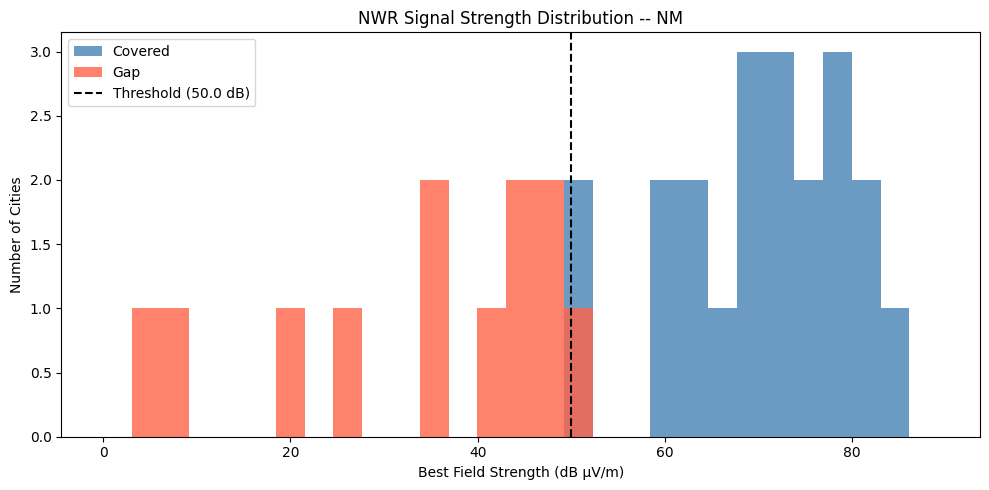

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

covered_sig = coverage_df.loc[ coverage_df['covered'],  'best_field_strength']
gap_sig     = coverage_df.loc[~coverage_df['covered'], 'best_field_strength']

bins = np.linspace(0, coverage_df['best_field_strength'].max() + 5, 30)
ax.hist(covered_sig, bins=bins, color='steelblue', alpha=0.8, label='Covered')
ax.hist(gap_sig,     bins=bins, color='tomato',    alpha=0.8, label='Gap')
ax.axvline(COVERAGE_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
           label=f'Threshold ({COVERAGE_THRESHOLD} dB)')

ax.set_xlabel('Best Field Strength (dB µV/m)')
ax.set_ylabel('Number of Cities')
ax.set_title(f'NWR Signal Strength Distribution -- {YOUR_STATE}')
ax.legend()
plt.tight_layout()
plt.show()

**Questions:**

1. Are gap cities clustered near the threshold (borderline) or far below it (deep gaps)?
2. What does the shape of the covered distribution tell you -- are most covered cities well above threshold or barely over it?
3. If you could place one new NWR transmitter anywhere in this state, where would you put it and why?

**Your answers:**

1. There is a pretty even split of cities close to the coverage border and deep gaps.
2. Covered cities sit well above the threshold. THey have good margins of error.
3. I would put one in Grants since it has the worst coverage in the sample and it has a great central location that could possibly extend to cover nearby communities that also have gaps.

---
## Week 4 Reflection

1. A city-level sweep counts places but misses people who live *outside* city limits -- farms, rural communities, unincorporated areas. How significant is that blind spot for this research?
2. Did the rural hypothesis hold for your state? What additional evidence would it take to convince you the pattern is real, not just geographic coincidence?
3. In Week 5 you'll scale to the full United States. Describe your sampling strategy -- will you query every city, filter by population, or sample per state? What tradeoffs does your approach make?
4. The 50 dB threshold is an engineering assumption built into the RadioLand model, not a regulatory standard. What would it take to establish a formal threshold -- and who should have the authority to set it?

**Your answers:**

1. This is a very signifigant blind spot especially in states with large rural areas like New Mexico with plenty of farms and ranches.
2. The rural hypothesis held for NM. There was a large gap between metro and non-metro coverage. To support this, I would need to see similar trends in very different states like in the north east.
3. It is probably better to sample by state at first because it is unrealistic to sample every single city. Counties could be a better approach but would still take time. Per state sampling would not caputre true rural blind spots which we think are so important to this study.
4. Setting a real threshold standard would take us buttering up a lot of FCC officials and even possibly action from the House and Senate commities responsible for NWR coverage. We would need a lot of direct data and history stating that individuals with less than 50db were let down in many situations of natural disasters.